# Fine-tune RT-DETR on BDD100K
The idea is to take the pretrained RT-DETR model (trained on COCO + Objects365)
and fine-tune it on our BDD100K dataset so it learns BDD-specific classes.

## Step 1 — Imports

In [17]:
import json
import os
import matplotlib.pyplot as plt
import albumentations as A
import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import AutoImageProcessor, RTDetrForObjectDetection

print("GPU available:", torch.cuda.is_available())
print(
    "GPU name    :",
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU",
)

GPU available: True
GPU name    : NVIDIA GeForce RTX 4050 Laptop GPU


## Step 2 — Set your paths and training config here
Only thing you need to change — point to your BDD100K files

In [14]:
# ── Your BDD100K paths ────────────────────────────────────────────────────────
TRAIN_JSON = r"D:\BOsch\assignment_data_bdd\bdd100k_labels_release\bdd100k\labels\bdd100k_labels_images_train.json"
VAL_JSON = r"D:\BOsch\assignment_data_bdd\bdd100k_labels_release\bdd100k\labels\bdd100k_labels_images_val.json"
TRAIN_IMG_DIR = (
    r"D:\BOsch\assignment_data_bdd\bdd100k_images_100k\bdd100k\images\100k\train"
)
VAL_IMG_DIR = (
    r"D:\BOsch\assignment_data_bdd\bdd100k_images_100k\bdd100k\images\100k\val"
)

# ── Training config ───────────────────────────────────────────────────────────
num_images = 500
NUM_EPOCHS = 5
BATCH_SIZE = 5  # 2 kyunki zydaa smaples se problem hogi
LR = 1e-4
IMAGE_SIZE = 640  # RT-DETR input size
OUTPUT_DIR = r"D:\BOsch\rtdetr_bdd_output_model"

os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", DEVICE)

Training on: cuda


## Step 3 — Define BDD classes
BDD100K has 10 object classes we care about.
We create id2label and label2id maps — the model needs these.

In [8]:
BDD_CLASSES = [
    "pedestrian",  # 0
    "rider",  # 1
    "car",  # 2
    "truck",  # 3
    "bus",  # 4
    "train",  # 5
    "motor",  # 6
    "bike",  # 7
    "traffic light",  # 8
    "traffic sign",  # 9
]

id2label = {i: name for i, name in enumerate(BDD_CLASSES)}
label2id = {name: i for i, name in enumerate(BDD_CLASSES)}

print("Classes:", id2label)

Classes: {0: 'pedestrian', 1: 'rider', 2: 'car', 3: 'truck', 4: 'bus', 5: 'train', 6: 'motor', 7: 'bike', 8: 'traffic light', 9: 'traffic sign'}


## Step 4 — Parse BDD100K JSON
BDD stores annotations in its own JSON format.
We parse it and convert bounding boxes to COCO format [x, y, width, height]

In [9]:
def parse_bdd_json(json_path, img_dir):
    """
    Reads BDD JSON and returns a list of samples.
    Each sample = { image_path, bboxes (COCO format), labels (int ids) }
    """
    with open(json_path) as f:
        data = json.load(f)

    samples = []

    for item in data:
        img_path = os.path.join(img_dir, item["name"])

        # skip if image file doesn't exist
        if not os.path.exists(img_path):
            continue

        bboxes = []
        labels = []

        for label in item.get("labels", []):
            cat = label.get("category", "")

            # skip classes not in our 10-class list
            if cat not in label2id:
                continue

            box2d = label.get("box2d")
            if box2d is None:
                continue

            x1, y1, x2, y2 = box2d["x1"], box2d["y1"], box2d["x2"], box2d["y2"]
            w = x2 - x1
            h = y2 - y1

            if w <= 0 or h <= 0:
                continue

            bboxes.append([x1, y1, w, h])  # COCO format
            labels.append(label2id[cat])

        samples.append(
            {
                "image_path": img_path,
                "bboxes": bboxes,
                "labels": labels,
            }
        )

    return samples


print("Parsing train JSON...")
train_samples = parse_bdd_json(TRAIN_JSON, TRAIN_IMG_DIR)
train_samples = train_samples[
    :num_images
]  # small dataset is fine , just to see , if its working
print(f"  → {len(train_samples)} train images")

print("Parsing val JSON...")
val_samples = parse_bdd_json(VAL_JSON, VAL_IMG_DIR)
val_samples = val_samples[:num_images]
print(f"  → {len(val_samples)} val images")

Parsing train JSON...
  → 500 train images
Parsing val JSON...
  → 500 val images


## Step 5 — PyTorch Dataset
Wraps our parsed samples into a Dataset that the DataLoader can use.
Also applies image augmentations during training.

In [10]:
# Augmentations for training (random flips, brightness, blur etc.)
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.Blur(blur_limit=3, p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="coco", label_fields=["labels"], clip=True, min_area=25
    ),
)

# No augmentation for validation — just use image as-is
val_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(format="coco", label_fields=["labels"], clip=True),
)


class BDDDataset(Dataset):

    def __init__(self, samples, image_processor, transform):
        self.samples = samples
        self.image_processor = image_processor
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # load image
        image = np.array(Image.open(sample["image_path"]).convert("RGB"))

        # apply augmentations
        out = self.transform(
            image=image, bboxes=sample["bboxes"], labels=sample["labels"]
        )
        image = out["image"]
        bboxes = out["bboxes"]
        labels = out["labels"]

        # format annotations the way HuggingFace image processor expects
        annotations = {
            "image_id": idx,
            "annotations": [
                {
                    "image_id": idx,
                    "category_id": cat,
                    "bbox": list(bbox),  # [x, y, w, h]
                    "area": bbox[2] * bbox[3],
                    "iscrowd": 0,
                }
                for bbox, cat in zip(bboxes, labels)
            ],
        }

        # let the image processor resize + normalize the image
        encoding = self.image_processor(
            images=[image], annotations=[annotations], return_tensors="pt"
        )

        # remove the batch dimension added by image_processor
        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "labels": encoding["labels"][0],
        }


print("Dataset class defined.")

Dataset class defined.


## Step 6 — Load RT-DETR model + image processor
- Downloads from HuggingFace on first run, then cached locally
- ignore_mismatched_sizes=True because pretrained model has 365 classes, we have 10

In [ ]:
# reduces memory usage significantly on your 6GB GPU
torch.backends.cuda.matmul.allow_tf32 = True

In [11]:
MODEL_ID = "PekingU/rtdetr_r50vd_coco_o365"

image_processor = AutoImageProcessor.from_pretrained(
    MODEL_ID,
    do_resize=True,
    size={"height": IMAGE_SIZE, "width": IMAGE_SIZE},
)

model = RTDetrForObjectDetection.from_pretrained(
    MODEL_ID,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,  # re-initializes the head from 365 → 10 classes
)

model = model.to(DEVICE)

print("Model loaded on:", DEVICE)
print(
    "Number of parameters:",
    sum(p.numel() for p in model.parameters()) // 1_000_000,
    "M",
)

The image processor of type `RTDetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 764/764 [00:00<00:00, 1779.44it/s]
RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r50vd_coco_o365
Key                                                 | Status   |                                                                                         
----------------------------------------------------+----------+-----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([10])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to si

Model loaded on: cuda
Number of parameters: 42 M


## Step 7 — Create DataLoaders
DataLoader feeds batches of images to the model during training

In [12]:
def collate_fn(batch):
    """Stacks pixel_values into a tensor, keeps labels as a list"""
    return {
        "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
        "labels": [x["labels"] for x in batch],
    }


train_dataset = BDDDataset(train_samples, image_processor, train_transform)
val_dataset = BDDDataset(val_samples, image_processor, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # 2 , keeping this to zero as to  avoids multiprocessing issues
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # for same reason
    collate_fn=collate_fn,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train batches : 100
Val batches   : 100


## Step 8 — Optimizer
AdamW is standard for transformer models.
We use a lower LR for the backbone (already pretrained) and higher for the head (freshly initialized).

In [ ]:
# backbone gets 10x smaller learning rate — it's already well trained
# head gets full learning rate — it's freshly initialized
optimizer = torch.optim.AdamW(
    [
        {"params": model.model.backbone.parameters(), "lr": LR / 10},
        {"params": model.model.encoder.parameters(), "lr": LR},
        {"params": model.model.decoder.parameters(), "lr": LR},
    ],
    lr=LR,
    weight_decay=1e-4,
)

print("Optimizer ready.")

Optimizer ready.


## Step 9 — Training loop
- Loops over all epochs
- For each batch: forward pass → compute loss → backward → update weights
- Prints train loss and val loss every epoch
- Saves best model checkpoint automatically

In [ ]:
best_val_loss = float("inf")
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):

    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [train]"):

        pixel_values = batch["pixel_values"].to(DEVICE)
        labels = [{k: v.to(DEVICE) for k, v in t.items()} for t in batch["labels"]]

        # forward pass — model computes loss internally
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [val]  "):

            pixel_values = batch["pixel_values"].to(DEVICE)
            labels = [{k: v.to(DEVICE) for k, v in t.items()} for t in batch["labels"]]

            outputs = model(pixel_values=pixel_values, labels=labels)
            epoch_val_loss += outputs.loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"\nEpoch {epoch+1:02d} → Train Loss: {avg_train_loss:.4f}  |  Val Loss: {avg_val_loss:.4f}"
    )

    # ── Save best model ───────────────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        model.save_pretrained(OUTPUT_DIR)
        image_processor.save_pretrained(OUTPUT_DIR)
        print(f"   ✓ Best model saved (val loss: {best_val_loss:.4f})")

print("\nTraining complete!")
print(f"Best model saved to: {OUTPUT_DIR}")

Epoch 1/5 [val]  : 100%|██████████| 100/100 [00:38<00:00,  2.58it/s]



Epoch 01 → Train Loss: 27.3165  |  Val Loss: 15.0615


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.99it/s]


   ✓ Best model saved (val loss: 15.0615)


Epoch 2/5 [val]  : 100%|██████████| 100/100 [00:36<00:00,  2.72it/s]


...


Epoch 04 → Train Loss: 17.4824  |  Val Loss: 11.5655


Epoch 5/5 [val]  : 100%|██████████| 100/100 [00:37<00:00,  2.64it/s]



Epoch 05 → Train Loss: 16.9238  |  Val Loss: 11.1578


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.99it/s]

   ✓ Best model saved (val loss: 11.1578)

Training complete!
Best model saved to: ./rtdetr_bdd_output_model


## Step 10 — Plot training curves
Shows how train and val loss decreased over epochs

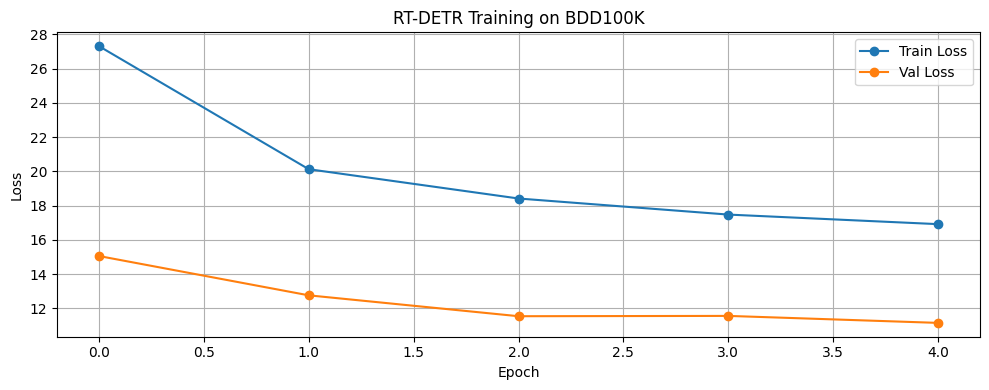

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RT-DETR Training on BDD100K")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 11 — Quick check: run inference on a val image with the trained model
Load the saved model and run it on one image to see predictions

Loading weights: 100%|██████████| 764/764 [00:00<00:00, 2624.69it/s]


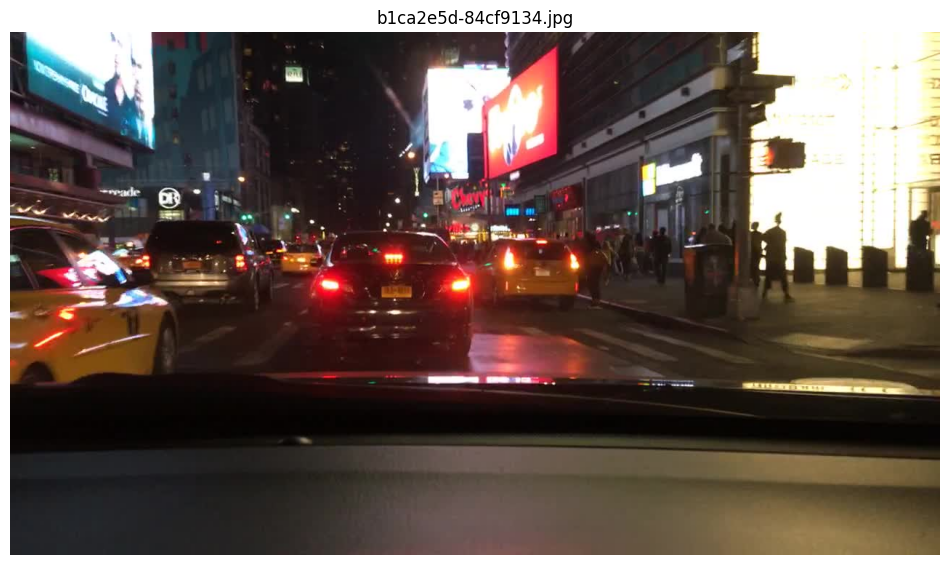

In [18]:
# load the saved best model
trained_model = RTDetrForObjectDetection.from_pretrained(OUTPUT_DIR)
trained_model = trained_model.to(DEVICE)
trained_model.eval()

# pick fifth val image ,, koi bhiimage pe test kar skate hai
sample = val_samples[4]
image = Image.open(sample["image_path"]).convert("RGB")
inputs = image_processor(images=image, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = trained_model(**inputs)

# post-process predictions
results = image_processor.post_process_object_detection(
    outputs, threshold=0.5, target_sizes=[image.size[::-1]]  # (height, width)
)[0]

# visualize
plt.figure(figsize=(12, 7))
plt.imshow(image)
ax = plt.gca()

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    x1, y1, x2, y2 = box.cpu().numpy()
    rect = plt.Rectangle(
        (x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2, color="red"
    )
    ax.add_patch(rect)
    ax.text(
        x1,
        y1,
        f"{id2label[label.item()]} {score:.2f}",
        color="red",
        bbox=dict(facecolor="yellow", alpha=0.5),
    )

plt.title(os.path.basename(sample["image_path"]))
plt.axis("off")
plt.show()

In [19]:
print(results)

{'scores': tensor([], device='cuda:0'), 'labels': tensor([], device='cuda:0', dtype=torch.int64), 'boxes': tensor([], device='cuda:0', size=(0, 4))}


In [ ]:
print(results.keys())

dict_keys(['map', 'map_50', 'map_75', 'map_small', 'map_medium', 'map_large', 'mar_1', 'mar_10', 'mar_100', 'mar_small', 'mar_medium', 'mar_large', 'map_per_class', 'mar_100_per_class', 'classes'])
